In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import types as T
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql.types import StringType
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid", context="notebook")


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Разработка системы анализа медицинских изображений для эпидемиологического мониторинга COVID-19

**Цель проекта**

Разработать аналитическую систему для эпидемиологического мониторинга COVID-19 на основе метаданных рентгеновских снимков, используя стек PySpark.


**Датасет**
Используется репозиторий COVID-19 Chest X-Ray Dataset, который содержит:

Метаданные: файл metadata.csv с полями:

`patientid` (идентификатор пациента)

`age` (возраст, есть не для всех записей)

`sex` (пол, не для всех записей)

`finding` (диагноз: COVID-19, Pneumonia, Normal и другие)

`view` (проекция снимка: PA, AP и так далее)

`date` (дата исследования)

### 1. Подготовка среды

Настроить рабочее окружение с PySpark (локально или в Google Colab).
    
Убедиться, что Spark-сессия корректно запускается.
    
Проверить работу базовых операций с данными.


In [50]:
spark = SparkSession.builder.appName("CovidXray").getOrCreate()

In [64]:
df = spark.read.csv(
    "./covid-chestxray-dataset/metadata.csv",  # локальный путь, HDFS или S3
    header=True,
    inferSchema=True
)
df.printSchema()
df.show(5)

root
 |-- patientid: string (nullable = true)
 |-- offset: integer (nullable = true)
 |-- sex: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- finding: string (nullable = true)
 |-- RT_PCR_positive: string (nullable = true)
 |-- survival: string (nullable = true)
 |-- intubated: string (nullable = true)
 |-- intubation_present: string (nullable = true)
 |-- went_icu: string (nullable = true)
 |-- in_icu: string (nullable = true)
 |-- needed_supplemental_O2: string (nullable = true)
 |-- extubated: string (nullable = true)
 |-- temperature: double (nullable = true)
 |-- pO2_saturation: double (nullable = true)
 |-- leukocyte_count: double (nullable = true)
 |-- neutrophil_count: double (nullable = true)
 |-- lymphocyte_count: double (nullable = true)
 |-- view: string (nullable = true)
 |-- modality: string (nullable = true)
 |-- date: string (nullable = true)
 |-- location: string (nullable = true)
 |-- folder: string (nullable = true)
 |-- filename: string (nullable 

25/12/02 23:22:33 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: patientid, offset, sex, age, finding, RT_PCR_positive, survival, intubated, intubation_present, went_icu, in_icu, needed_supplemental_O2, extubated, temperature, pO2_saturation, leukocyte_count, neutrophil_count, lymphocyte_count, view, modality, date, location, folder, filename, doi, url, license, clinical_notes, other_notes, 
 Schema: patientid, offset, sex, age, finding, RT_PCR_positive, survival, intubated, intubation_present, went_icu, in_icu, needed_supplemental_O2, extubated, temperature, pO2_saturation, leukocyte_count, neutrophil_count, lymphocyte_count, view, modality, date, location, folder, filename, doi, url, license, clinical_notes, other_notes, _c29
Expected: _c29 but found: 
CSV file: file:///home/geonode/Рабочий%20стол/Неделя_1/mephi/spark/covid-chestxray-dataset/metadata.csv


In [65]:
df.select("RT_PCR_positive").distinct().show(100, truncate=False)

+---------------+
|RT_PCR_positive|
+---------------+
|Y              |
|Unclear        |
|NULL           |
+---------------+



In [66]:
df.select("date").distinct().show(100, truncate=False)

+------------------+
|date              |
+------------------+
|December 30, 2019 |
|2016              |
|2020              |
|2/29/2020         |
|September 16, 2009|
|February 4, 2020  |
|January 6, 2020   |
|January 28, 2020  |
|Oct 8, 2010       |
|2019              |
|2017              |
|2014              |
|2013              |
|December 29, 2019 |
|12 March 2020     |
|03/06/20          |
|May 4, 2010       |
|2018              |
|June 5, 2017      |
|Mar 5, 2020       |
|Feb 16, 2020      |
|January 1, 2020   |
|February 18, 2020 |
|March 5, 2020     |
|Mar 4, 2020       |
|January 26, 2020  |
|Feb 18, 2020      |
|Feb 21, 2020      |
|September 10, 2009|
|February 25, 2020 |
|September 21, 2009|
|January 12        |
|Feb 17, 2020      |
|March 10, 2020    |
|2004              |
|03/16/20          |
|January 20        |
|2011              |
|January 19, 2020  |
|Jan 28, 2020      |
|May 10, 2015      |
|January 23, 2020  |
|January 31, 2020  |
|December 27, 2019 |
|2007        

### 2. Предобработка данных

Очистка метаданных:

Заполнить пропуски в данных.

Унифицировать диагнозы.

Удалить дубликаты.


In [75]:
# 1. Чистим исходные строки
df = df.withColumn(
    "date_clean",
    F.when(
        F.trim("date").isin("", "NULL"),  # пусто или "NULL"
        None
    ).otherwise(F.trim("date"))          # обрезаем пробелы вокруг
)

# 2. Пробуем все форматы по очереди
df = df.withColumn(
    "date_norm",
    F.coalesce(
        # January 22, 2020 / February 4, 2020 / March 10, 2020 ...
        F.to_date("date_clean", "MMMM d, yyyy"),

        # Jan 24, 2020 / Mar 3, 2020 / Oct 8, 2010 ...
        F.to_date("date_clean", "MMM d, yyyy"),

        # 3/3/2020 / 3/7/2020 ...
        F.to_date("date_clean", "M/d/yyyy"),

        # 03/06/20 / 11/27/19 ...
        F.to_date("date_clean", "MM/dd/yy"),

        # March 2020 / June 2017 ...
        F.to_date("date_clean", "MMMM yyyy"),

        # 2017 / 2019 / 2020 ...
        F.to_date("date_clean", "yyyy"),
    )
)

In [79]:
spark.range(1).select(
    F.to_date(F.lit("January 22, 2020"), "MMMM d, yyyy").alias("full_month"),
    F.to_date(F.lit("Mar 3, 2020"), "MMM d, yyyy").alias("short_month"),
    F.to_date(F.lit("3/3/2020"), "M/d/yyyy").alias("mdy_slash"),
    F.to_date(F.lit("2017"), "yyyy").alias("year_only")
).show(truncate=False)


+----------+-----------+----------+----------+
|full_month|short_month|mdy_slash |year_only |
+----------+-----------+----------+----------+
|2020-01-22|2020-03-03 |2020-03-03|2017-01-01|
+----------+-----------+----------+----------+



In [85]:
col_raw = "date"

# Очистка — как выше
df = df.withColumn(
    "date_str",
    F.trim(F.col(col_raw).cast("string"))
)

df = df.withColumn(
    "date_str",
    F.when(F.col("date_str").isin("", "NULL", "null", "None"), None)
     .otherwise(F.col("date_str"))
)

df = df.withColumn(
    "date_str",
    F.regexp_replace("date_str", "[\u00A0\u2007\u202F\t\r\n]", " ")
)

df = df.withColumn(
    "date_str",
    F.regexp_replace("date_str", "[^0-9A-Za-z/,\- ]", " ")
)

df = df.withColumn("date_str", F.regexp_replace("date_str", " +", " "))
df = df.withColumn("date_str", F.trim("date_str"))

# Парсинг через try_to_timestamp + приведение к date
df = df.withColumn(
    "date_parsed",
    F.coalesce(
        F.expr("cast(try_to_timestamp(date_str, 'MMMM d, yyyy') as date)"),
        F.expr("cast(try_to_timestamp(date_str, 'MMM d, yyyy') as date)"),
        F.expr("cast(try_to_timestamp(date_str, 'MMMM yyyy') as date)"),
        F.expr("cast(try_to_timestamp(date_str, 'M/d/yyyy') as date)"),
        F.expr("cast(try_to_timestamp(date_str, 'MM/dd/yyyy') as date)"),
        F.expr("cast(try_to_timestamp(date_str, 'M/d/yy') as date)"),
        F.expr("cast(try_to_timestamp(date_str, 'MM/dd/yy') as date)"),
        F.expr("cast(try_to_timestamp(date_str, 'yyyy') as date)")
    )
)

df.select(col_raw, "date_str", "date_parsed").show(100, False)

+-----------------+-----------------+-----------+
|date             |date_str         |date_parsed|
+-----------------+-----------------+-----------+
|January 22, 2020 |January 22, 2020 |2020-01-22 |
|January 25, 2020 |January 25, 2020 |2020-01-25 |
|January 27, 2020 |January 27, 2020 |2020-01-27 |
|January 28, 2020 |January 28, 2020 |2020-01-28 |
|January 25, 2020 |January 25, 2020 |2020-01-25 |
|January 30, 2020 |January 30, 2020 |2020-01-30 |
|2017             |2017             |2017-01-01 |
|January 6, 2020  |January 6, 2020  |2020-01-06 |
|January 10, 2020 |January 10, 2020 |2020-01-10 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |


In [86]:
# Посмотреть результат
df.select(col_raw, "date_str", "date_parsed").show(100, False)

+-----------------+-----------------+-----------+
|date             |date_str         |date_parsed|
+-----------------+-----------------+-----------+
|January 22, 2020 |January 22, 2020 |2020-01-22 |
|January 25, 2020 |January 25, 2020 |2020-01-25 |
|January 27, 2020 |January 27, 2020 |2020-01-27 |
|January 28, 2020 |January 28, 2020 |2020-01-28 |
|January 25, 2020 |January 25, 2020 |2020-01-25 |
|January 30, 2020 |January 30, 2020 |2020-01-30 |
|2017             |2017             |2017-01-01 |
|January 6, 2020  |January 6, 2020  |2020-01-06 |
|January 10, 2020 |January 10, 2020 |2020-01-10 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |
|2004             |2004             |2004-01-01 |


In [89]:
df = df.drop("date_norm")

In [90]:
df.select("date_parsed").show(100, truncate=False)


+-----------+
|date_parsed|
+-----------+
|2020-01-22 |
|2020-01-25 |
|2020-01-27 |
|2020-01-28 |
|2020-01-25 |
|2020-01-30 |
|2017-01-01 |
|2020-01-06 |
|2020-01-10 |
|2004-01-01 |
|2004-01-01 |
|2004-01-01 |
|2004-01-01 |
|2004-01-01 |
|2004-01-01 |
|2004-01-01 |
|2004-01-01 |
|2004-01-01 |
|2004-01-01 |
|2004-01-01 |
|2020-01-01 |
|2020-01-01 |
|2020-01-19 |
|2020-01-19 |
|2020-01-22 |
|2020-01-22 |
|2020-01-24 |
|2020-01-26 |
|2020-01-26 |
|2020-01-01 |
|2020-01-01 |
|2020-01-01 |
|2020-01-01 |
|2020-01-01 |
|2020-01-25 |
|2020-01-31 |
|2020-02-06 |
|2020-01-31 |
|2020-02-06 |
|2020-01-01 |
|2020-01-20 |
|2020-01-23 |
|2020-01-27 |
|2020-02-04 |
|2020-02-06 |
|2020-02-06 |
|2020-02-06 |
|2020-02-06 |
|2020-01-01 |
|2020-01-01 |
|2020-01-01 |
|2020-01-01 |
|2020-01-01 |
|2020-01-01 |
|2020-01-01 |
|2020-01-01 |
|2020-01-01 |
|2020-01-01 |
|2019-02-26 |
|2015-05-10 |
|2017-06-05 |
|2010-05-04 |
|2010-05-04 |
|2019-05-09 |
|2010-10-08 |
|2014-01-01 |
|2014-01-01 |
|2014-01-01 |
|2014-

In [88]:
df.printSchema()
df.show(5)

root
 |-- patientid: string (nullable = true)
 |-- offset: integer (nullable = true)
 |-- sex: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- finding: string (nullable = true)
 |-- RT_PCR_positive: string (nullable = true)
 |-- survival: string (nullable = true)
 |-- intubated: string (nullable = true)
 |-- intubation_present: string (nullable = true)
 |-- went_icu: string (nullable = true)
 |-- in_icu: string (nullable = true)
 |-- needed_supplemental_O2: string (nullable = true)
 |-- extubated: string (nullable = true)
 |-- temperature: double (nullable = true)
 |-- pO2_saturation: double (nullable = true)
 |-- leukocyte_count: double (nullable = true)
 |-- neutrophil_count: double (nullable = true)
 |-- lymphocyte_count: double (nullable = true)
 |-- view: string (nullable = true)
 |-- modality: string (nullable = true)
 |-- date: string (nullable = true)
 |-- location: string (nullable = true)
 |-- folder: string (nullable = true)
 |-- filename: string (nullable 

25/12/02 23:39:19 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: patientid, offset, sex, age, finding, RT_PCR_positive, survival, intubated, intubation_present, went_icu, in_icu, needed_supplemental_O2, extubated, temperature, pO2_saturation, leukocyte_count, neutrophil_count, lymphocyte_count, view, modality, date, location, folder, filename, doi, url, license, clinical_notes, other_notes, 
 Schema: patientid, offset, sex, age, finding, RT_PCR_positive, survival, intubated, intubation_present, went_icu, in_icu, needed_supplemental_O2, extubated, temperature, pO2_saturation, leukocyte_count, neutrophil_count, lymphocyte_count, view, modality, date, location, folder, filename, doi, url, license, clinical_notes, other_notes, _c29
Expected: _c29 but found: 
CSV file: file:///home/geonode/Рабочий%20стол/Неделя_1/mephi/spark/covid-chestxray-dataset/metadata.csv


In [91]:
# Приведение age к числу и фильтр нереальных значений:

In [92]:
df = df.withColumn("age", F.col("age").cast("double"))
df = df.filter((F.col("age").isNull()) | ((F.col("age") > 0) & (F.col("age") < 120)))


patientid, finding — желательно не заполнять суррогатами, лучше удалить строки без них.

age, sex, view можно заполнить.


**Удалить строки без patientid или finding:**

In [93]:
df = df.filter(F.col("patientid").isNotNull() & F.col("finding").isNotNull())

In [94]:
median_age = df.approxQuantile("age", [0.5], 0.01)[0]  # быстрая медиана

df = df.withColumn(
    "age",
    F.when(F.col("age").isNull(), F.lit(median_age)).otherwise(F.col("age"))
)

**Унификация диагнозов (finding)**

В metadata.csv finding часто содержит комбинации:

"COVID-19"

"COVID-19, ARDS"

"Pneumonia"

"Viral Pneumonia"

"No finding"

 и т.п.


In [95]:
df.select("finding").distinct().orderBy("finding").show(100, truncate=False)


+---------------------------------------+
|finding                                |
+---------------------------------------+
|No Finding                             |
|Pneumonia                              |
|Pneumonia/Aspiration                   |
|Pneumonia/Bacterial                    |
|Pneumonia/Bacterial/Chlamydophila      |
|Pneumonia/Bacterial/E.Coli             |
|Pneumonia/Bacterial/Klebsiella         |
|Pneumonia/Bacterial/Legionella         |
|Pneumonia/Bacterial/Mycoplasma         |
|Pneumonia/Bacterial/Nocardia           |
|Pneumonia/Bacterial/Staphylococcus/MRSA|
|Pneumonia/Bacterial/Streptococcus      |
|Pneumonia/Fungal/Aspergillosis         |
|Pneumonia/Fungal/Pneumocystis          |
|Pneumonia/Lipoid                       |
|Pneumonia/Viral/COVID-19               |
|Pneumonia/Viral/Herpes                 |
|Pneumonia/Viral/Influenza              |
|Pneumonia/Viral/Influenza/H1N1         |
|Pneumonia/Viral/MERS-CoV               |
|Pneumonia/Viral/SARS             

In [96]:
df = df.withColumn("finding_clean", F.lower(F.col("finding")))

df = df.withColumn(
    "finding_clean",
    F.when(F.col("finding_clean").rlike("covid"), "COVID-19")
     .when(F.col("finding_clean").rlike("pneumonia"), "Pneumonia")
     .when(
         (F.col("finding_clean").rlike("no finding")) |
         (F.col("finding_clean").rlike("normal")),
         "Normal"
     )
     .otherwise("Other")
)

df = df.drop("finding").withColumnRenamed("finding_clean", "finding")


**Удаление дубликатов**

Часто в этом датасете по одному пациенту несколько снимков в разные даты или разные проекции — это полезная информация. Что считать дубликатом, зависит от задачи.

Частые варианты:

Удалить одинаковые строки (полный дубликат):

In [97]:
df = df.dropDuplicates()


In [98]:
df = df.dropDuplicates(["patientid", "date", "view"])


In [102]:
w = Window.partitionBy("patientid").orderBy(F.col("date").desc_nulls_last())

df = (
    df.withColumn("rn", F.row_number().over(w))
      .filter(F.col("rn") == 1)
      .drop("rn")
)

**сохранить результат:**

In [104]:
df.write.mode("overwrite").parquet("metadata_parquet")

25/12/03 21:46:59 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: patientid, offset, sex, age, finding, RT_PCR_positive, survival, intubated, intubation_present, went_icu, in_icu, needed_supplemental_O2, extubated, temperature, pO2_saturation, leukocyte_count, neutrophil_count, lymphocyte_count, view, modality, date, location, folder, filename, doi, url, license, clinical_notes, other_notes, 
 Schema: patientid, offset, sex, age, finding, RT_PCR_positive, survival, intubated, intubation_present, went_icu, in_icu, needed_supplemental_O2, extubated, temperature, pO2_saturation, leukocyte_count, neutrophil_count, lymphocyte_count, view, modality, date, location, folder, filename, doi, url, license, clinical_notes, other_notes, _c29
Expected: _c29 but found: 
CSV file: file:///home/geonode/Рабочий%20стол/Неделя_1/mephi/spark/covid-chestxray-dataset/metadata.csv


### 3. Анализ качества данных

Построить распределение пропущенных значений по всем полям.

Выявить и обработать аномальные значения.

Задокументировать обнаруженные проблемы данных.

In [105]:
# считать сохранённые данные
metadata_df = spark.read.parquet("metadata_parquet")

Числовые: ['offset', 'age', 'temperature', 'pO2_saturation', 'leukocyte_count', 'neutrophil_count', 'lymphocyte_count']
Даты: []
Строковые/категориальные: ['patientid', 'sex', 'RT_PCR_positive', 'survival', 'intubated', 'intubation_present', 'went_icu', 'in_icu', 'needed_supplemental_O2', 'extubated', 'view', 'modality', 'date', 'location', 'folder', 'filename', 'doi', 'url', 'license', 'clinical_notes', 'other_notes', '_c29', 'date_clean', 'date_str', 'date_parsed', 'finding']


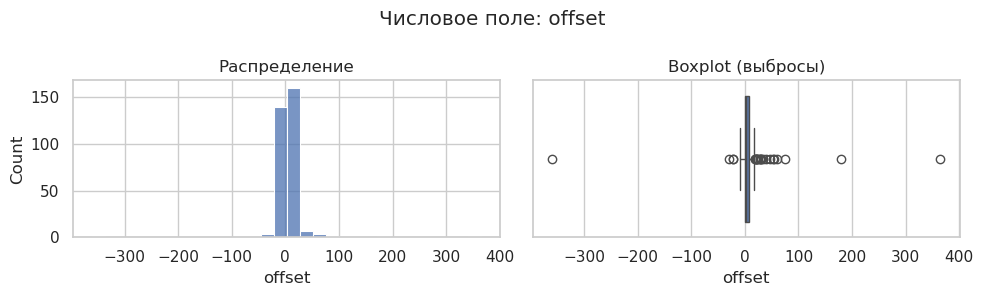

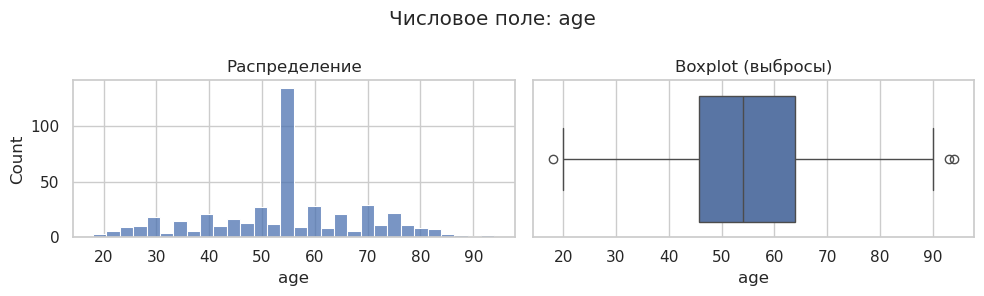

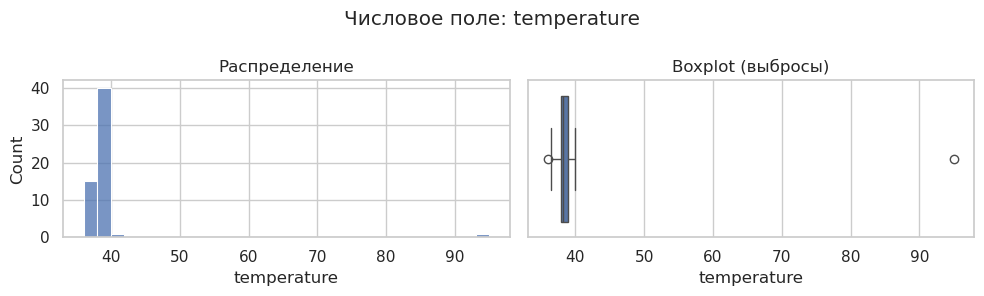

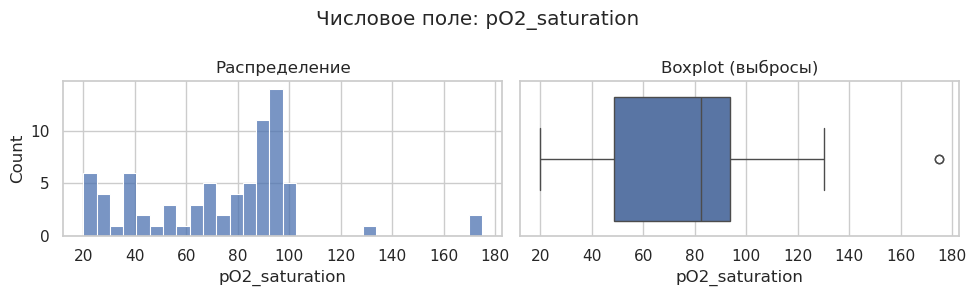

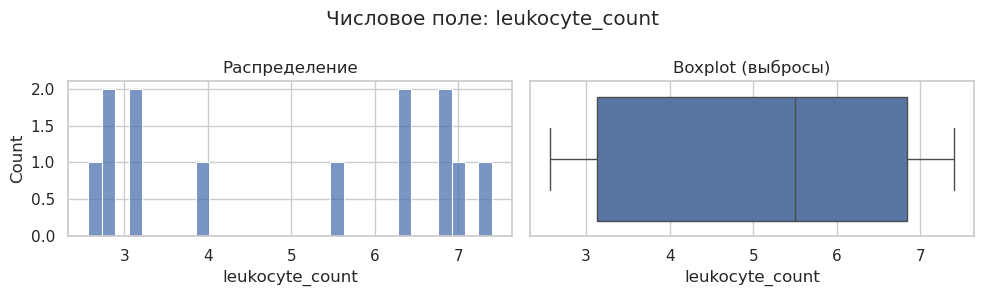

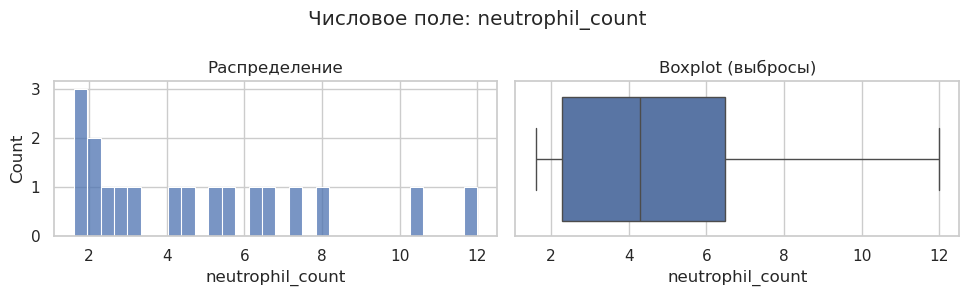

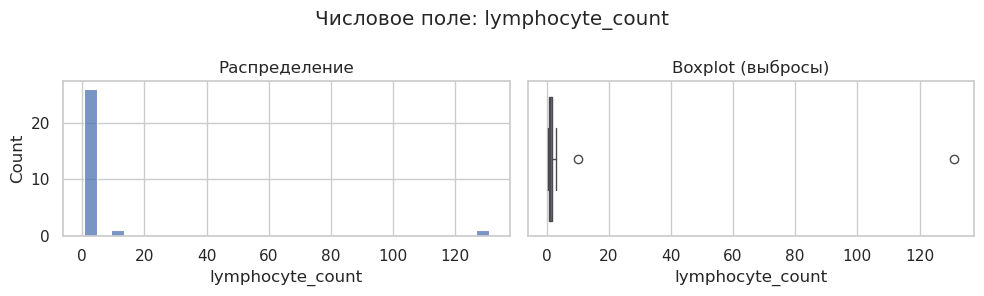

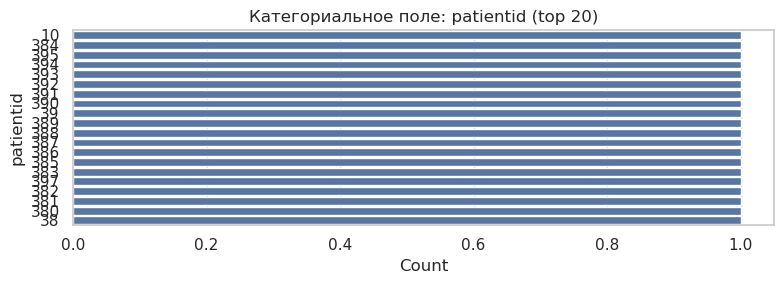

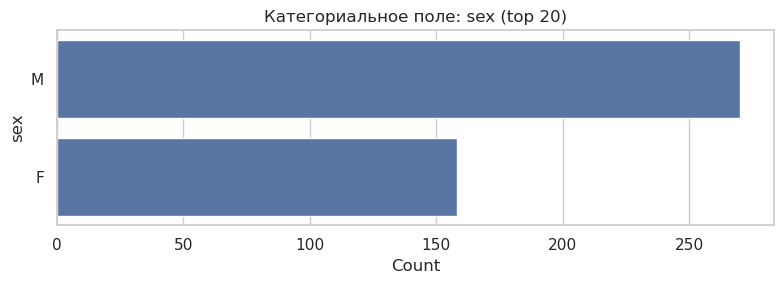

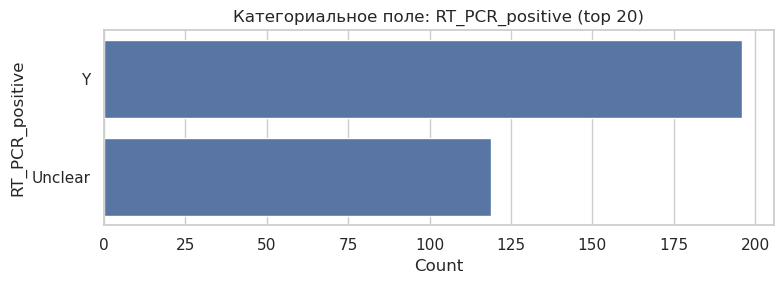

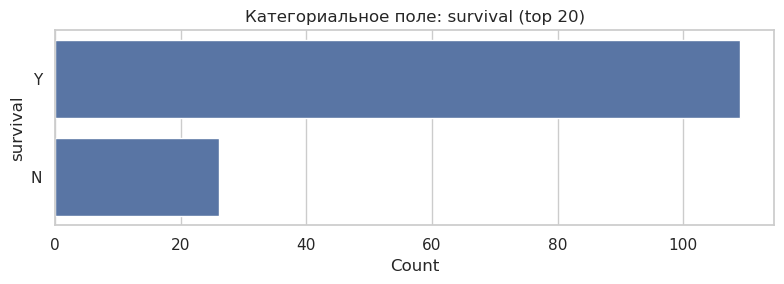

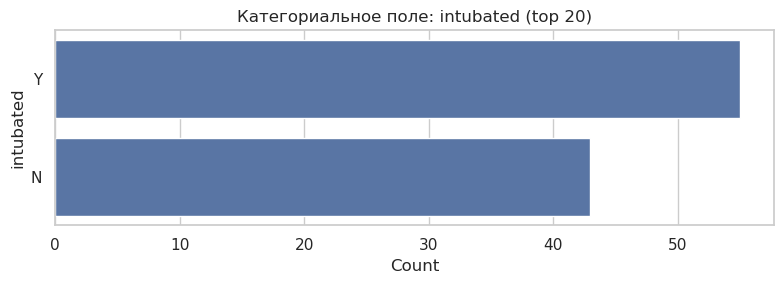

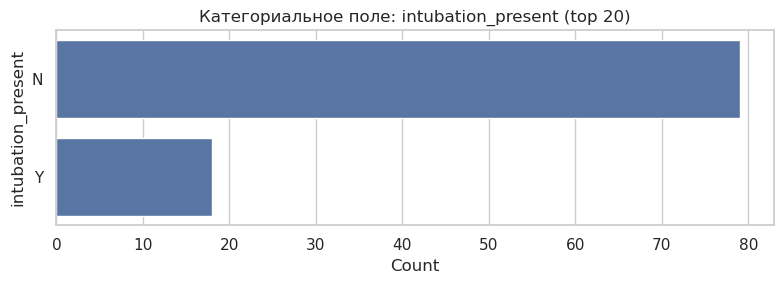

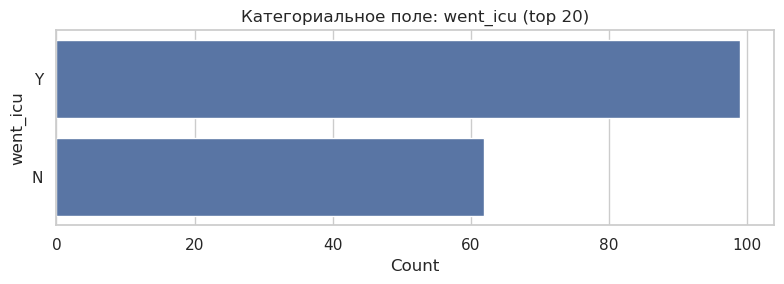

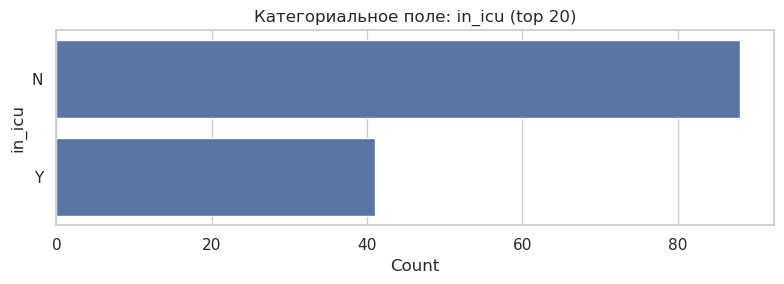

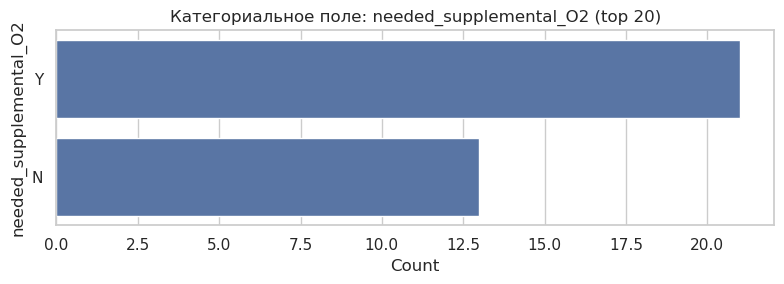

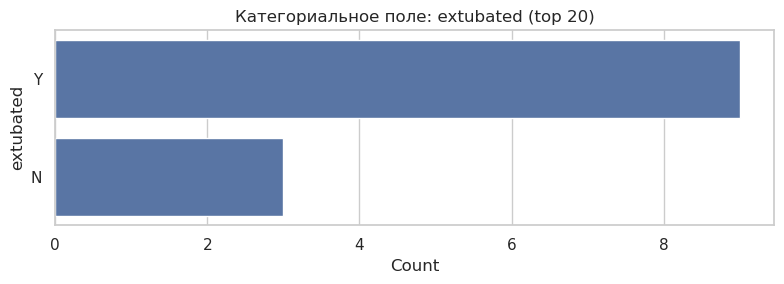

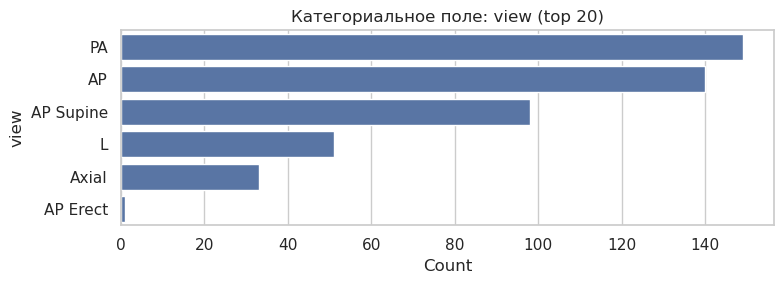

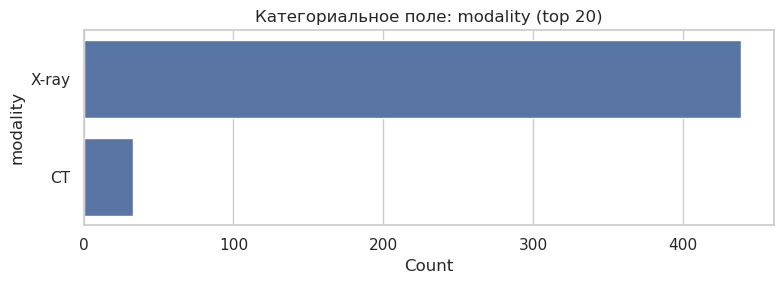

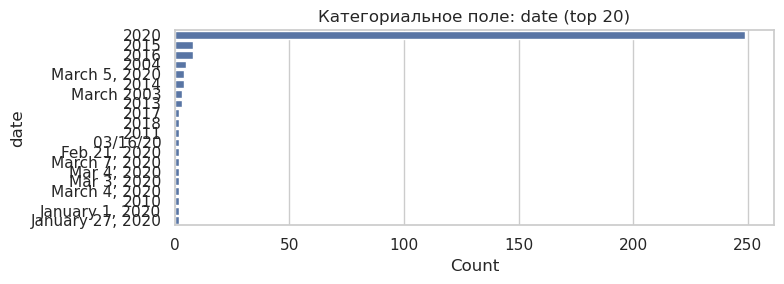

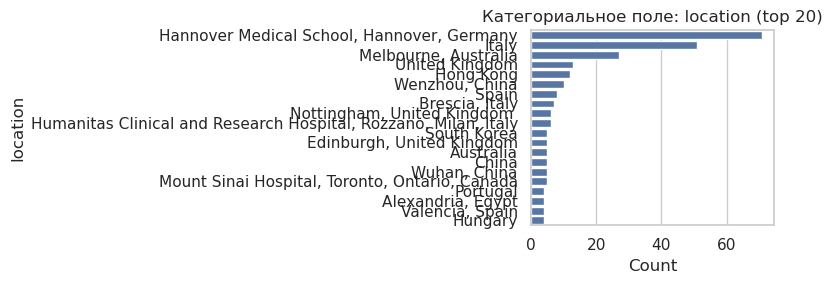

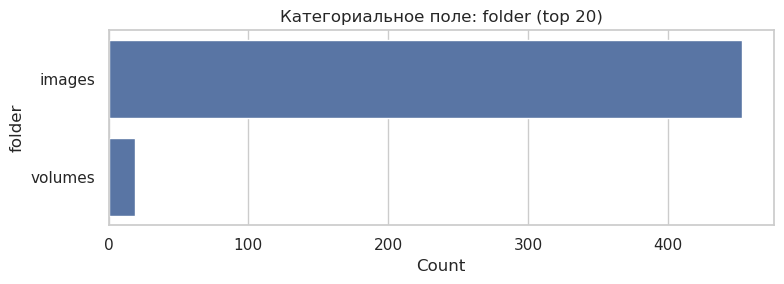

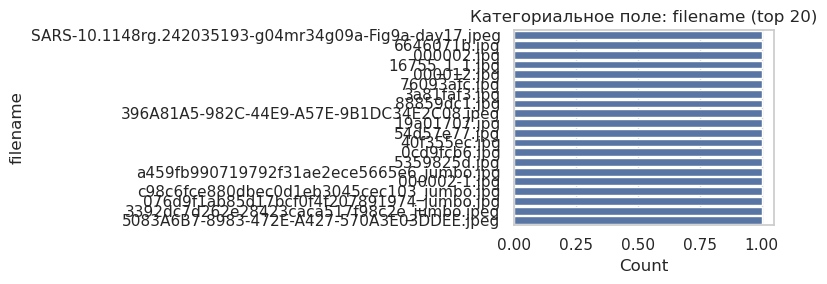

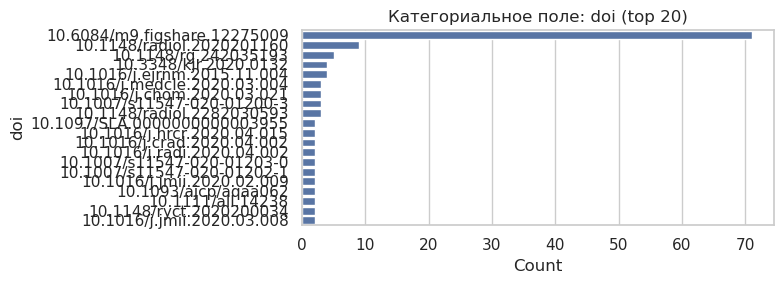

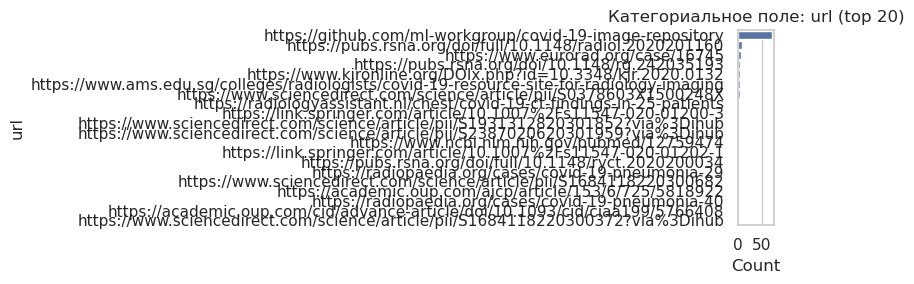

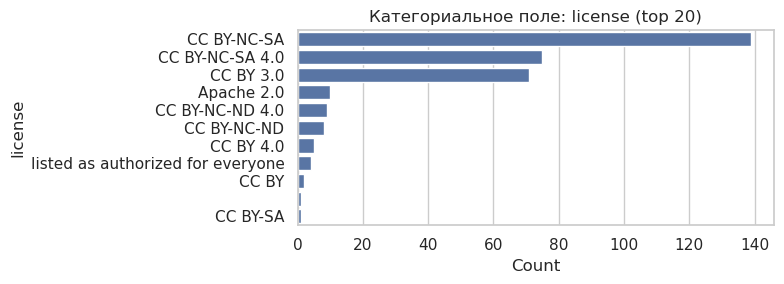

/tmp/ipykernel_2191123/2455438933.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


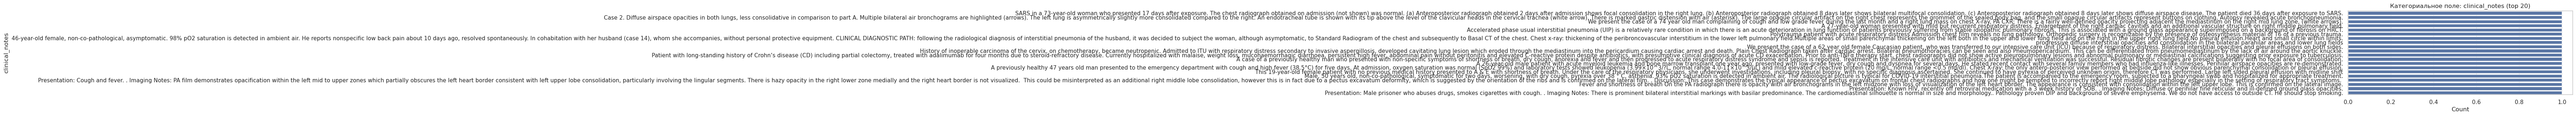

/tmp/ipykernel_2191123/2455438933.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


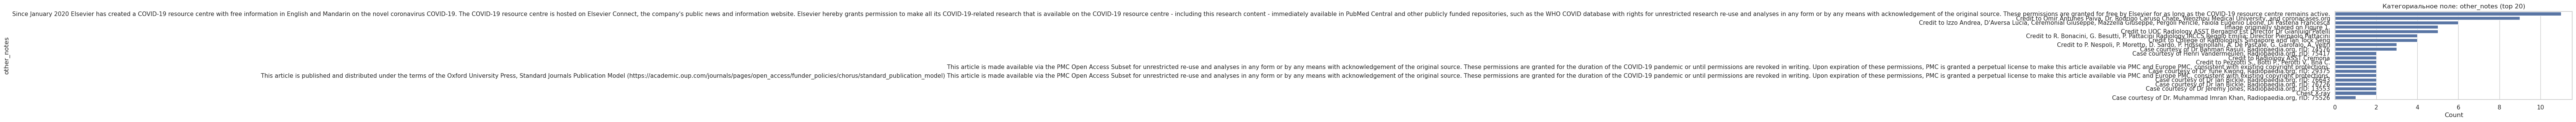

/tmp/ipykernel_2191123/2455438933.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


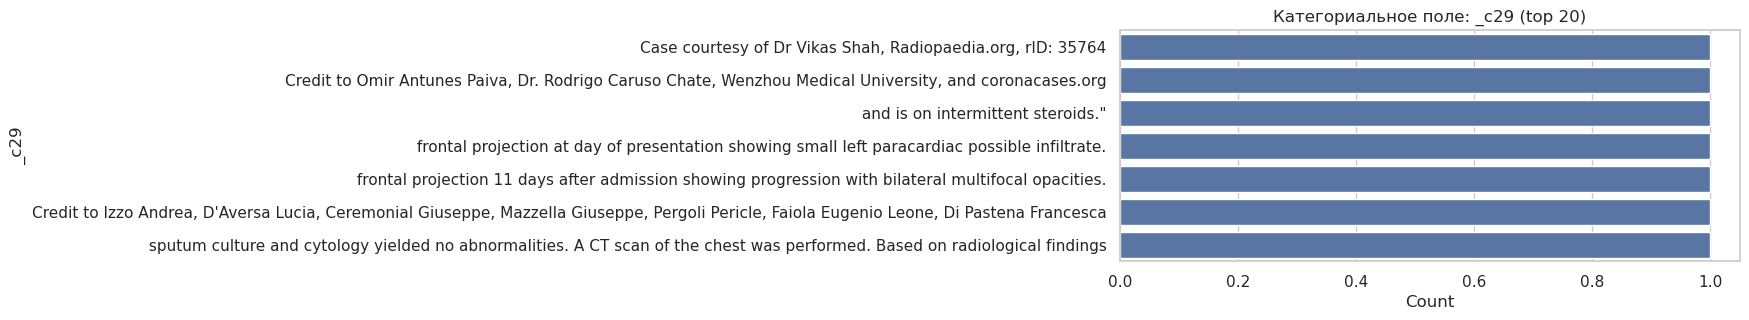

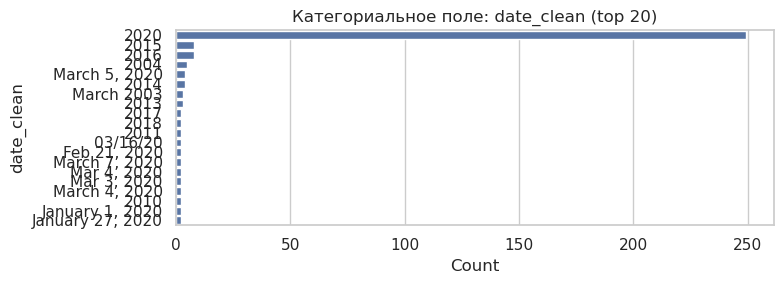

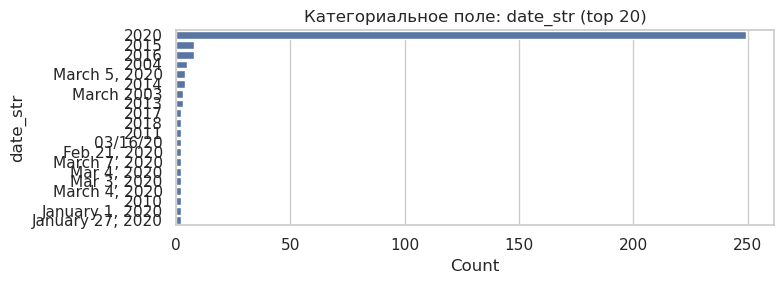

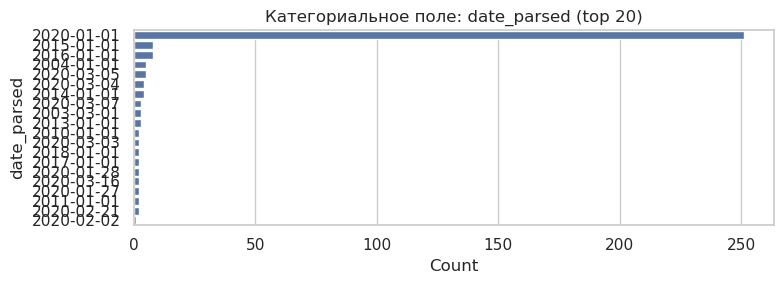

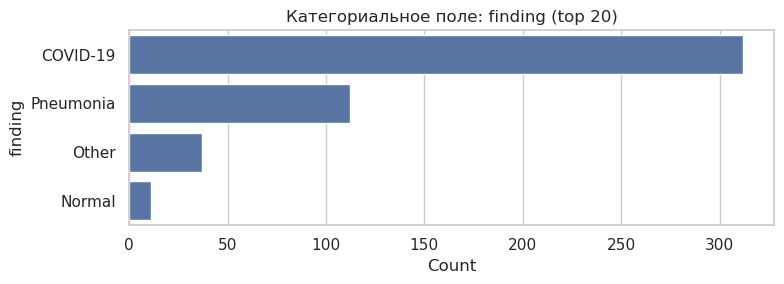

In [111]:
# 1. Берём сэмпл (важно, иначе большой датасет не влезет в память)
sample_size = 10000
pdf = df.limit(sample_size).toPandas()

# 2. Определяем типы колонок по pandas dtypes
numeric_cols = pdf.select_dtypes(include=["int64", "float64"]).columns.tolist()
datetime_cols = pdf.select_dtypes(include=["datetime64[ns]"]).columns.tolist()
object_cols  = pdf.select_dtypes(include=["object"]).columns.tolist()

print("Числовые:", numeric_cols)
print("Даты:", datetime_cols)
print("Строковые/категориальные:", object_cols)

sns.set(style="whitegrid")

# 3. Числовые — гистограмма + boxplot для каждого столбца
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    fig.suptitle(f"Числовое поле: {col}")

    # гистограмма
    sns.histplot(pdf[col].dropna(), bins=30, ax=axes[0])
    axes[0].set_title("Распределение")
    
    # boxplot
    sns.boxplot(x=pdf[col].dropna(), ax=axes[1])
    axes[1].set_title("Boxplot (выбросы)")
    
    plt.tight_layout()
    plt.show()

# 4. Даты — простое распределение по времени (countplot по дате)
for col in datetime_cols:
    # округлим до дня/месяца по необходимости
    tmp = pdf[col].dropna().dt.to_period("M").dt.to_timestamp()
    plt.figure(figsize=(10, 3))
    sns.countplot(x=tmp)
    plt.xticks(rotation=45)
    plt.title(f"Дата/время: {col}")
    plt.tight_layout()
    plt.show()

# 5. Категориальные — барплот для топ-k категорий
top_k = 20  # сколько категорий показывать максимум

for col in object_cols:
    vc = pdf[col].value_counts().head(top_k)
    plt.figure(figsize=(8, 3))
    sns.barplot(x=vc.values, y=vc.index, orient="h")
    plt.title(f"Категориальное поле: {col} (top {top_k})")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [107]:
# если вы в Databricks / Jupyter с интеграцией:
display(metadata_df)  # Databricks


DataFrame[patientid: string, offset: int, sex: string, age: double, RT_PCR_positive: string, survival: string, intubated: string, intubation_present: string, went_icu: string, in_icu: string, needed_supplemental_O2: string, extubated: string, temperature: double, pO2_saturation: double, leukocyte_count: double, neutrophil_count: double, lymphocyte_count: double, view: string, modality: string, date: string, location: string, folder: string, filename: string, doi: string, url: string, license: string, clinical_notes: string, other_notes: string, _c29: string, date_clean: string, date_str: string, date_parsed: date, finding: string]

**3.1. Распределение пропусков по всем полям**

In [114]:
df = metadata_df  # ваш датафрейм
rows_count = df.count()

agg_exprs = []

for field in df.schema.fields:
    c = field.name
    # для строковых полей считаем пропусками NULL и пустые строки
    if isinstance(field.dataType, StringType):
        cond = F.col(c).isNull() | (F.trim(F.col(c)) == "")
    # для остальных только NULL
    else:
        cond = F.col(c).isNull()
    agg_exprs.append(F.count(F.when(cond, 1)).alias(c))

missing_stats_sdf = df.agg(*agg_exprs)

missing_stats = (
    missing_stats_sdf.toPandas()
    .T
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing_stats["missing_ratio"] = missing_stats["missing_count"] / rows_count
missing_stats = missing_stats.sort_values("missing_ratio", ascending=False)

missing_stats


,column,missing_count,missing_ratio
28,_c29,465,0.985169
11,extubated,460,0.974576
14,leukocyte_count,459,0.972458
15,neutrophil_count,454,0.961864
16,lymphocyte_count,444,0.940678
10,needed_supplemental_O2,438,0.927966
12,temperature,415,0.879237
13,pO2_saturation,396,0.838983
7,intubation_present,375,0.794492
6,intubated,374,0.792373


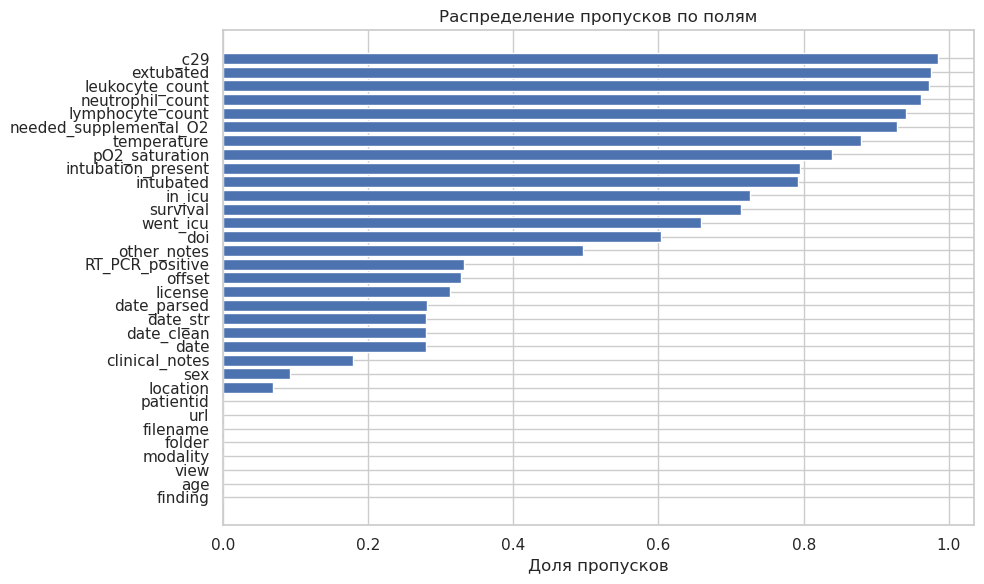

In [115]:
plt.figure(figsize=(10, 6))
plt.barh(missing_stats["column"], missing_stats["missing_ratio"])
plt.gca().invert_yaxis()
plt.xlabel("Доля пропусков")
plt.title("Распределение пропусков по полям")
plt.tight_layout()
plt.show()


**3.2. Выявление аномальных значений**

In [116]:
numeric_cols = ["offset", "age", "temperature", "pO2_saturation",
                "leukocyte_count", "neutrophil_count", "lymphocyte_count"]

df.describe(numeric_cols).show(truncate=False)


+-------+-----------------+------------------+------------------+-----------------+------------------+------------------+------------------+
|summary|offset           |age               |temperature       |pO2_saturation   |leukocyte_count   |neutrophil_count  |lymphocyte_count  |
+-------+-----------------+------------------+------------------+-----------------+------------------+------------------+------------------+
|count  |317              |472               |57                |76               |13                |18                |28                |
|mean   |5.621451104100946|54.29661016949152 |39.214035087719296|74.21447368421053|4.99923076923077  |4.888888888888888 |6.1222142857142865|
|stddev |31.95985288798763|14.966521349613325|7.562984071791732 |31.18897114450285|1.9114107422636888|3.0798546353948915|24.540698039148708|
|min    |-360             |18.0              |36.0              |20.0             |2.57              |1.6               |0.4               |
|max    |365 

• age: 0 ≤ age ≤ 120

• temperature (С): 30 ≤ temp ≤ 45

• pO2_saturation: 0 ≤ sat ≤ 100

• offset: ожидается ≥ 0, если это смещение по времени от события.

• клеточные показатели (leukocyte_count, neutrophil_count, lymphocyte_count):
  отрицательные значения заведомо аномальны; нереалистично большие — кандидаты в аномалии (см. IQR).

In [ ]:
rules = [
    ("age < 0 OR age > 120", "age_out_of_range"),
    ("temperature < 30 OR temperature > 45", "temperature_out_of_range"),
    ("pO2_saturation < 0 OR pO2_saturation > 100", "pO2_out_of_range"),
    ("offset < 0", "offset_negative"),
    ("leukocyte_count < 0", "leukocyte_negative"),
    ("neutrophil_count < 0", "neutrophil_negative"),
    ("lymphocyte_count < 0", "lymphocyte_negative"),
]

anomalies = df
for cond, flag_name in rules:
    anomalies = anomalies.withColumn(flag_name, F.expr(cond).cast("int"))

# Посчитаем количество записей, нарушающих каждое правило
summary_anomalies = anomalies.select([
    F.sum(F.col(flag)).alias(flag) for _, flag in rules
])

summary_anomalies.show()


поиска выбросов по статистике (IQR):

In [118]:
quantiles = df.approxQuantile(numeric_cols, [0.25, 0.75], 0.05)
iqr_bounds = {}

for col, (q1, q3) in zip(numeric_cols, quantiles):
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_bounds[col] = (lower, upper)

iqr_bounds

{'offset': (-10.5, 17.5),
 'age': (20.0, 84.0),
 'temperature': (36.74999999999999, 39.550000000000004),
 'pO2_saturation': (-27.0, 165.0),
 'leukocyte_count': (-2.4000000000000012, 11.680000000000001),
 'neutrophil_count': (-4.1000000000000005, 12.700000000000001),
 'lymphocyte_count': (-0.9, 3.1)}

количество записей вне этих границ:

In [119]:
outlier_counts = []
for col, (lower, upper) in iqr_bounds.items():
    cnt = df.filter((F.col(col) < lower) | (F.col(col) > upper)).count()
    outlier_counts.append((col, cnt))

outlier_counts

[('offset', 24),
 ('age', 8),
 ('temperature', 6),
 ('pO2_saturation', 2),
 ('leukocyte_count', 0),
 ('neutrophil_count', 0),
 ('lymphocyte_count', 2)]

**3.2.2. Категориальные/бинарные поля**

In [120]:
flag_cols = ["RT_PCR_positive", "survival", "intubated", "intubation_present",
             "went_icu", "in_icu", "needed_supplemental_O2", "extubated"]

for c in flag_cols:
    print(f"==== {c} ====")
    df.groupBy(c).count().orderBy("count", ascending=False).show(truncate=False)


==== RT_PCR_positive ====
+---------------+-----+
|RT_PCR_positive|count|
+---------------+-----+
|Y              |196  |
|NULL           |157  |
|Unclear        |119  |
+---------------+-----+

==== survival ====
+--------+-----+
|survival|count|
+--------+-----+
|NULL    |337  |
|Y       |109  |
|N       |26   |
+--------+-----+

==== intubated ====
+---------+-----+
|intubated|count|
+---------+-----+
|NULL     |374  |
|Y        |55   |
|N        |43   |
+---------+-----+

==== intubation_present ====
+------------------+-----+
|intubation_present|count|
+------------------+-----+
|NULL              |375  |
|N                 |79   |
|Y                 |18   |
+------------------+-----+

==== went_icu ====
+--------+-----+
|went_icu|count|
+--------+-----+
|NULL    |311  |
|Y       |99   |
|N       |62   |
+--------+-----+

==== in_icu ====
+------+-----+
|in_icu|count|
+------+-----+
|NULL  |343  |
|N     |88   |
|Y     |41   |
+------+-----+

==== needed_supplemental_O2 ====
+----

In [121]:
yes_values = ["yes", "y", "1", "true", "positive"]
no_values  = ["no", "n", "0", "false", "negative"]

def normalize_flag(col):
    col_l = F.lower(F.trim(col))
    return (
        F.when(col_l.isin([v.lower() for v in yes_values]), F.lit("yes"))
         .when(col_l.isin([v.lower() for v in no_values]), F.lit("no"))
         .otherwise(F.lit(None))  # остальное считаем пропуском/неизвестным
    )

df_clean = df
for c in flag_cols:
    df_clean = df_clean.withColumn(c + "_norm", normalize_flag(F.col(c)))


**3.2.3. Даты**

In [122]:
df.select("date", "date_clean", "date_str", "date_parsed").show(20, truncate=False)

# какие даты не распарсились (если есть исходный парсинг)
df.filter(F.col("date_parsed").isNull() & F.col("date").isNotNull()).count()

+----+----------+--------+-----------+
|date|date_clean|date_str|date_parsed|
+----+----------+--------+-----------+
|2004|2004      |2004    |2004-01-01 |
|2014|2014      |2014    |2014-01-01 |
|2014|2014      |2014    |2014-01-01 |
|2007|2007      |2007    |2007-01-01 |
|2010|2010      |2010    |2010-01-01 |
|2015|2015      |2015    |2015-01-01 |
|2010|2010      |2010    |2010-01-01 |
|2016|2016      |2016    |2016-01-01 |
|2015|2015      |2015    |2015-01-01 |
|2015|2015      |2015    |2015-01-01 |
|2015|2015      |2015    |2015-01-01 |
|2020|2020      |2020    |2020-01-01 |
|2016|2016      |2016    |2016-01-01 |
|2016|2016      |2016    |2016-01-01 |
|2020|2020      |2020    |2020-01-01 |
|2020|2020      |2020    |2020-01-01 |
|2020|2020      |2020    |2020-01-01 |
|2020|2020      |2020    |2020-01-01 |
|2020|2020      |2020    |2020-01-01 |
|2020|2020      |2020    |2020-01-01 |
+----+----------+--------+-----------+
only showing top 20 rows


1

**3.3. Обработка аномальных значений**

In [123]:
df_fixed = df

df_fixed = df_fixed.withColumn(
    "age",
    F.when((F.col("age") < 0) | (F.col("age") > 120), None).otherwise(F.col("age"))
)

df_fixed = df_fixed.withColumn(
    "temperature",
    F.when((F.col("temperature") < 30) | (F.col("temperature") > 45), None)
     .otherwise(F.col("temperature"))
)

df_fixed = df_fixed.withColumn(
    "pO2_saturation",
    F.when((F.col("pO2_saturation") < 0) | (F.col("pO2_saturation") > 100), None)
     .otherwise(F.col("pO2_saturation"))
)

df_fixed = df_fixed.withColumn(
    "offset",
    F.when(F.col("offset") < 0, None).otherwise(F.col("offset"))
)

Для выбросов по IQR — можно сделать «усечение» (winsorizing) или тоже перевести в null. Пример усечения:

In [124]:
from functools import reduce

df_wins = df
for col, (lower, upper) in iqr_bounds.items():
    df_wins = df_wins.withColumn(
        col,
        F.when(F.col(col) < lower, lower)
         .when(F.col(col) > upper, upper)
         .otherwise(F.col(col))
    )

**3.4. Документация проблем данных**

In [125]:
flag_cols = ["RT_PCR_positive", "survival", "intubated", "intubation_present",
             "went_icu", "in_icu", "needed_supplemental_O2", "extubated"]

yes_values = ["yes", "y", "1", "true", "positive"]
no_values  = ["no", "n", "0", "false", "negative"]

def normalize_flag(col):
    col_l = F.lower(F.trim(col))
    return (
        F.when(col_l.isin([v.lower() for v in yes_values]), F.lit("yes"))
         .when(col_l.isin([v.lower() for v in no_values]), F.lit("no"))
         .otherwise(F.lit(None))
    )

df_clean = df
for c in flag_cols:
    df_clean = df_clean.withColumn(c + "_norm", normalize_flag(F.col(c)))


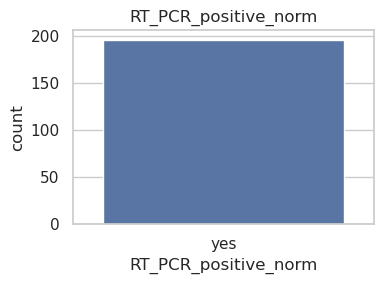

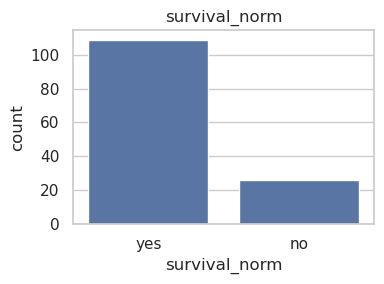

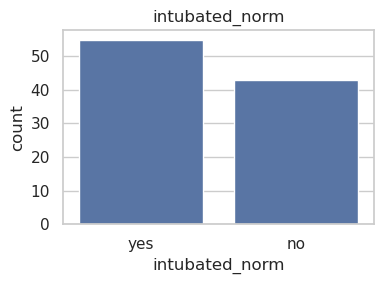

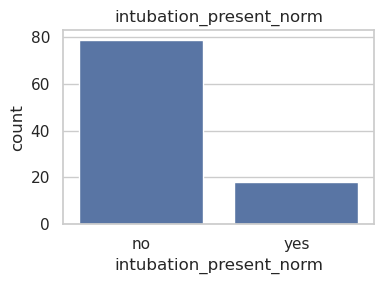

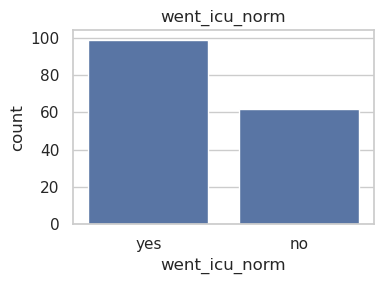

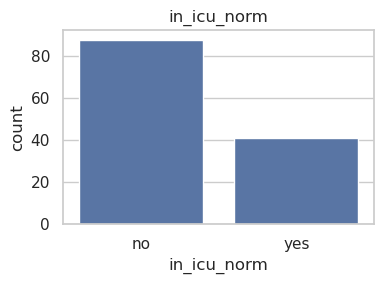

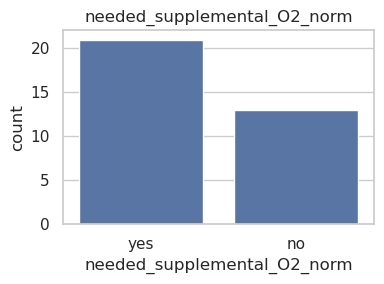

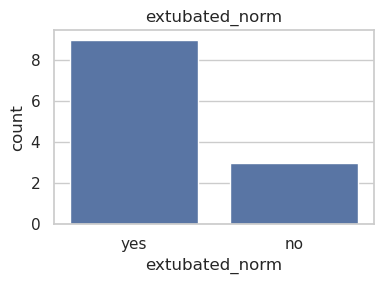

In [126]:
for c in flag_cols:
    col = c + "_norm"
    pdf = (
        df_clean.groupBy(col)
                .count()
                .toPandas()
                .sort_values("count", ascending=False)
    )
    plt.figure(figsize=(4, 3))
    sns.barplot(data=pdf, x=col, y="count")
    plt.title(col)
    plt.tight_layout()
    plt.show()


In [127]:
rows_count = df.count()
agg_exprs = []

for field in df.schema.fields:
    c = field.name
    if isinstance(field.dataType, StringType):
        cond = F.col(c).isNull() | (F.trim(F.col(c)) == "")
    else:
        cond = F.col(c).isNull()
    agg_exprs.append(F.count(F.when(cond, 1)).alias(c))

missing_stats_sdf = df.agg(*agg_exprs)

missing_stats = (
    missing_stats_sdf.toPandas()
    .T
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing_stats["missing_ratio"] = missing_stats["missing_count"] / rows_count
missing_stats = missing_stats.sort_values("missing_ratio", ascending=False)


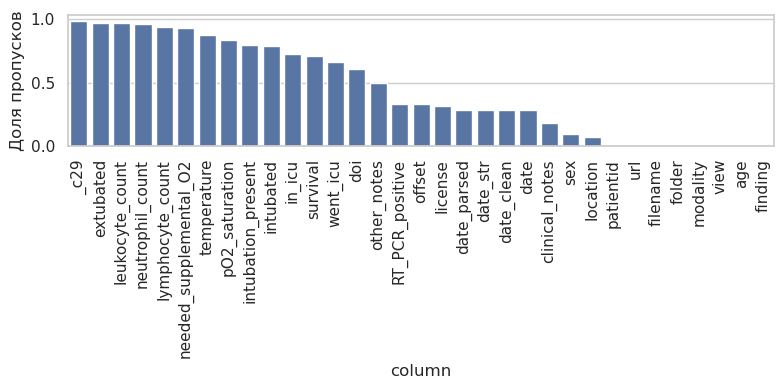

In [128]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=missing_stats,
    x="column",
    y="missing_ratio"
)
plt.xticks(rotation=90)
plt.ylabel("Доля пропусков")
plt.tight_layout()
plt.show()


In [130]:
df.select("date", "date_clean", "date_str", "date_parsed").show(10, truncate=False)


+----+----------+--------+-----------+
|date|date_clean|date_str|date_parsed|
+----+----------+--------+-----------+
|2004|2004      |2004    |2004-01-01 |
|2014|2014      |2014    |2014-01-01 |
|2014|2014      |2014    |2014-01-01 |
|2007|2007      |2007    |2007-01-01 |
|2010|2010      |2010    |2010-01-01 |
|2015|2015      |2015    |2015-01-01 |
|2010|2010      |2010    |2010-01-01 |
|2016|2016      |2016    |2016-01-01 |
|2015|2015      |2015    |2015-01-01 |
|2015|2015      |2015    |2015-01-01 |
+----+----------+--------+-----------+
only showing top 10 rows


/tmp/ipykernel_2191123/4247797279.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(pdf_before[col].dropna(), label="before", shade=True)
/tmp/ipykernel_2191123/4247797279.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(pdf_after[col].dropna(), label="after", shade=True)


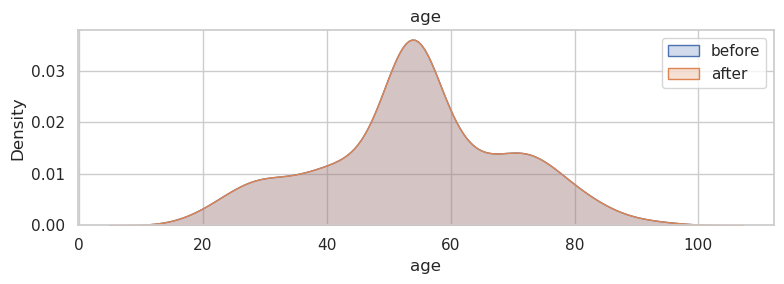

/tmp/ipykernel_2191123/4247797279.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(pdf_before[col].dropna(), label="before", shade=True)
/tmp/ipykernel_2191123/4247797279.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(pdf_after[col].dropna(), label="after", shade=True)


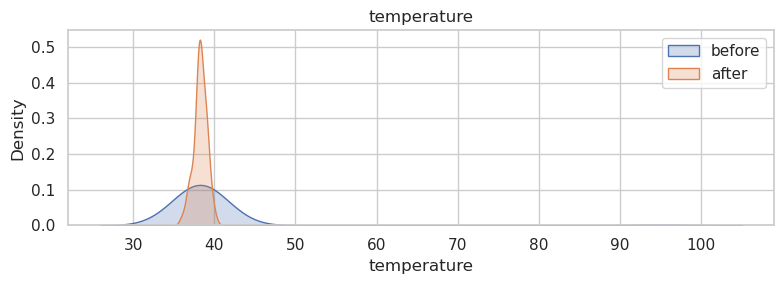

In [132]:
cols_num = ["age", "temperature"]

pdf_before = df.select(cols_num).toPandas()
pdf_after  = df_fixed.select(cols_num).toPandas()

for col in cols_num:
    plt.figure(figsize=(8, 3))
    sns.kdeplot(pdf_before[col].dropna(), label="before", shade=True)
    sns.kdeplot(pdf_after[col].dropna(), label="after", shade=True)
    plt.title(col)
    plt.legend()
    plt.tight_layout()
    plt.show()


### 4. SQL-аналитика
Пять обязательных запросов:

Запрос 1. Базовая статистика по диагнозам.

Запрос 2. Распределение по полу и диагнозам.

Запрос 3. Оконная функция (топ-3 по возрасту в каждой группе диагнозов).

Запрос 4. Анализ временных трендов по датам исследований.

Запрос 5. Статистика по проекциям снимков и их связи с диагнозами.

In [133]:
df_clean.createOrReplaceTempView("covid_studies")

In [136]:
df_clean

DataFrame[patientid: string, offset: int, sex: string, age: double, RT_PCR_positive: string, survival: string, intubated: string, intubation_present: string, went_icu: string, in_icu: string, needed_supplemental_O2: string, extubated: string, temperature: double, pO2_saturation: double, leukocyte_count: double, neutrophil_count: double, lymphocyte_count: double, view: string, modality: string, date: string, location: string, folder: string, filename: string, doi: string, url: string, license: string, clinical_notes: string, other_notes: string, _c29: string, date_clean: string, date_str: string, date_parsed: date, finding: string, RT_PCR_positive_norm: string, survival_norm: string, intubated_norm: string, intubation_present_norm: string, went_icu_norm: string, in_icu_norm: string, needed_supplemental_O2_norm: string, extubated_norm: string]

In [137]:
df

DataFrame[patientid: string, offset: int, sex: string, age: double, RT_PCR_positive: string, survival: string, intubated: string, intubation_present: string, went_icu: string, in_icu: string, needed_supplemental_O2: string, extubated: string, temperature: double, pO2_saturation: double, leukocyte_count: double, neutrophil_count: double, lymphocyte_count: double, view: string, modality: string, date: string, location: string, folder: string, filename: string, doi: string, url: string, license: string, clinical_notes: string, other_notes: string, _c29: string, date_clean: string, date_str: string, date_parsed: date, finding: string]

**Запрос 1. Базовая статистика по диагнозам**

In [140]:
# регистрируем временное представление
df_clean.createOrReplaceTempView("patients")

In [142]:
result = spark.sql("""
SELECT
    finding                                AS diagnosis,
    COUNT(*)                               AS exams_cnt,
    COUNT(DISTINCT patientid)              AS patients_cnt,
    ROUND(AVG(age), 1)                     AS avg_age,
    MIN(age)                               AS min_age,
    MAX(age)                               AS max_age
FROM patients
GROUP BY finding
ORDER BY exams_cnt DESC;
""")

result.show()   # или result.toPandas()


+---------+---------+------------+-------+-------+-------+
|diagnosis|exams_cnt|patients_cnt|avg_age|min_age|max_age|
+---------+---------+------------+-------+-------+-------+
| COVID-19|      312|         312|   56.3|   20.0|   94.0|
|Pneumonia|      112|         112|   49.9|   18.0|   90.0|
|    Other|       37|          37|   51.3|   20.0|   78.0|
|   Normal|       11|          11|   52.5|   22.0|   78.0|
+---------+---------+------------+-------+-------+-------+



**Запрос 2. Распределение по полу и диагнозам**

In [143]:
result = spark.sql("""
SELECT
    finding                       AS diagnosis,
    sex,
    COUNT(*)                      AS exams_cnt,
    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (PARTITION BY finding),
        1
    )                             AS pct_within_diagnosis
FROM patients
GROUP BY finding, sex
ORDER BY diagnosis, sex;
""")

result.show()   # или result.toPandas()


+---------+----+---------+--------------------+
|diagnosis| sex|exams_cnt|pct_within_diagnosis|
+---------+----+---------+--------------------+
| COVID-19|NULL|       35|                11.2|
| COVID-19|   F|      101|                32.4|
| COVID-19|   M|      176|                56.4|
|   Normal|   F|        5|                45.5|
|   Normal|   M|        6|                54.5|
|    Other|   F|        9|                24.3|
|    Other|   M|       28|                75.7|
|Pneumonia|NULL|        9|                 8.0|
|Pneumonia|   F|       43|                38.4|
|Pneumonia|   M|       60|                53.6|
+---------+----+---------+--------------------+



**Запрос 3. Оконная функция (топ-3 по возрасту в каждой группе диагнозов)**

In [144]:
result = spark.sql("""
SELECT
    diagnosis,
    patientid,
    sex,
    age,
    date_parsed,
    rn
FROM (
    SELECT
        finding                    AS diagnosis,
        patientid,
        sex,
        age,
        date_parsed,
        ROW_NUMBER() OVER (
            PARTITION BY finding
            ORDER BY age DESC, date_parsed ASC, patientid
        )                         AS rn
    FROM patients
) t
WHERE rn <= 3
ORDER BY diagnosis, rn;
""")

result.show()   # или result.toPandas()

+---------+---------+---+----+-----------+---+
|diagnosis|patientid|sex| age|date_parsed| rn|
+---------+---------+---+----+-----------+---+
| COVID-19|     326b|  M|94.0| 2020-01-01|  1|
| COVID-19|     324b|  F|93.0| 2020-01-01|  2|
| COVID-19|      200|  M|88.0|       NULL|  3|
|   Normal|      315|  F|78.0| 2020-03-04|  1|
|   Normal|      478|  F|75.0|       NULL|  2|
|   Normal|     313b|  M|75.0| 2020-01-01|  3|
|    Other|      421|  M|78.0|       NULL|  1|
|    Other|      453|  M|70.0|       NULL|  2|
|    Other|      456|  M|58.0|       NULL|  3|
|Pneumonia|      460|  M|90.0|       NULL|  1|
|Pneumonia|      340|  M|80.0| 2013-01-01|  2|
|Pneumonia|       91|  F|80.0| 2018-01-01|  3|
+---------+---------+---+----+-----------+---+



**Запрос 4. Анализ временных трендов по датам исследований**

In [145]:
result = spark.sql("""

SELECT
    DATE_TRUNC('month', date_parsed)          AS month,
    COUNT(*)                                  AS exams_cnt,
    SUM(CASE WHEN RT_PCR_positive_norm = 'yes' THEN 1 ELSE 0 END)
                                              AS pcr_pos_cnt,
    ROUND(
        100.0 *
        SUM(CASE WHEN RT_PCR_positive_norm = 'yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        1
    )                                         AS pcr_pos_pct
FROM patients
WHERE date_parsed IS NOT NULL
GROUP BY DATE_TRUNC('month', date_parsed)
ORDER BY month;
""")

result.show()   # или result.toPandas()

+-------------------+---------+-----------+-----------+
|              month|exams_cnt|pcr_pos_cnt|pcr_pos_pct|
+-------------------+---------+-----------+-----------+
|2003-03-01 00:00:00|        3|          0|        0.0|
|2004-01-01 00:00:00|        5|          0|        0.0|
|2007-01-01 00:00:00|        1|          0|        0.0|
|2009-09-01 00:00:00|        1|          0|        0.0|
|2010-01-01 00:00:00|        2|          0|        0.0|
|2010-05-01 00:00:00|        1|          0|        0.0|
|2010-10-01 00:00:00|        1|          0|        0.0|
|2011-01-01 00:00:00|        2|          0|        0.0|
|2013-01-01 00:00:00|        3|          0|        0.0|
|2014-01-01 00:00:00|        4|          0|        0.0|
|2015-01-01 00:00:00|        8|          0|        0.0|
|2015-05-01 00:00:00|        1|          0|        0.0|
|2016-01-01 00:00:00|        8|          0|        0.0|
|2017-01-01 00:00:00|        2|          0|        0.0|
|2017-06-01 00:00:00|        1|          0|     

**Запрос 5. Статистика по проекциям снимков и их связи с диагнозами**

In [146]:
result = spark.sql("""
SELECT
    view,
    finding                                AS diagnosis,
    COUNT(*)                               AS exams_cnt,
    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (PARTITION BY finding),
        1
    )                                      AS pct_of_diagnosis_by_view,
    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (PARTITION BY view),
        1
    )                                      AS pct_within_view
FROM patients
GROUP BY view, finding
ORDER BY diagnosis, exams_cnt DESC;


""")

result.show()   # или result.toPandas()

+---------+---------+---------+------------------------+---------------+
|     view|diagnosis|exams_cnt|pct_of_diagnosis_by_view|pct_within_view|
+---------+---------+---------+------------------------+---------------+
|       AP| COVID-19|      100|                    32.1|           71.4|
|       PA| COVID-19|       97|                    31.1|           65.1|
|AP Supine| COVID-19|       69|                    22.1|           70.4|
|    Axial| COVID-19|       30|                     9.6|           90.9|
|        L| COVID-19|       16|                     5.1|           31.4|
|       AP|   Normal|        4|                    36.4|            2.9|
|    Axial|   Normal|        3|                    27.3|            9.1|
|       PA|   Normal|        3|                    27.3|            2.0|
|AP Supine|   Normal|        1|                     9.1|            1.0|
|AP Supine|    Other|       18|                    48.6|           18.4|
|       PA|    Other|       11|                    

In [147]:
result = spark.sql("""
SELECT
    view,
    COUNT(*) AS exams_cnt
FROM patients
GROUP BY view
ORDER BY exams_cnt DESC;
""")

result.show()   # или result.toPandas()


+---------+---------+
|     view|exams_cnt|
+---------+---------+
|       PA|      149|
|       AP|      140|
|AP Supine|       98|
|        L|       51|
|    Axial|       33|
| AP Erect|        1|
+---------+---------+



### 5. Обработка в PySpark

Использование UDF:

Реализация пользовательской функции для категоризации возраста.

Унификация диагнозов.

Базовая обработка:

Фильтрация данных по заданным критериям.

Сохранение результатов в оптимизированном формате.

**5.1. UDF для категоризации возраста и унификации диагнозов**

In [148]:
from pyspark.sql.functions import udf, col
from pyspark.sql.types import StringType

# 1) Категоризация возраста
def age_bucket(age):
    if age is None:
        return "unknown"
    try:
        a = float(age)
    except (TypeError, ValueError):
        return "unknown"
    if a < 0:
        return "invalid"
    elif a < 18:
        return "child"
    elif a < 45:
        return "young_adult"
    elif a < 65:
        return "middle_aged"
    else:
        return "elderly"

age_bucket_udf = udf(age_bucket, StringType())

# 2) Унификация диагнозов
diagnosis_map = {
    "covid-19": "COVID-19",
    "covid": "COVID-19",
    "sars-cov-2": "COVID-19",
    "pneumonia": "Pneumonia",
    "viral pneumonia": "Pneumonia",
    "bacterial pneumonia": "Pneumonia",
    "no finding": "Normal",
    "normal": "Normal",
}

def normalize_diagnosis(raw):
    if raw is None:
        return "Unknown"
    key = str(raw).strip().lower()
    if key in diagnosis_map:
        return diagnosis_map[key]
    # по умолчанию — просто аккуратно вернуть исходное значение
    return str(raw).strip()

diagnosis_udf = udf(normalize_diagnosis, StringType())

# Применяем UDF и создаём новые столбцы
df_proc = (
    df_clean
    .withColumn("age_group", age_bucket_udf(col("age")))
    .withColumn("diagnosis_norm", diagnosis_udf(col("finding")))
)


**5.2. Базовая фильтрация данных**

возраст в разумных пределах;

корректный пол;

есть дата исследования;

есть нормализованный диагноз (не Unknown).


In [149]:
df_filtered = (
    df_proc
    # возраст 0–100
    .filter(col("age").isNotNull())
    .filter(col("age").cast("double").between(0, 100))
    # только M / F
    .filter(col("sex").isin("M", "F"))
    # дата не null
    .filter(col("date_parsed").isNotNull())
    # исключаем "Unknown" и "invalid"
    .filter(col("age_group").isin("child", "young_adult", "middle_aged", "elderly"))
    .filter(col("diagnosis_norm") != "Unknown")
)


**5.3. Сохранение результатов в оптимизированном формате**

В формате Parquet (сжатие Snappy, разбиение по диагностике и возрастной группе)

In [151]:
output_path_parquet = "patients_parquet"

(
    df_filtered
    .repartition("diagnosis_norm", "age_group")  # укрупняем партиции по логичным ключам
    .write
    .mode("overwrite")
    .partitionBy("diagnosis_norm", "age_group")
    .option("compression", "snappy")
    .parquet(output_path_parquet)
)


### 6. Визуализация

**6.1. Круговая диаграмма распределения диагнозов**

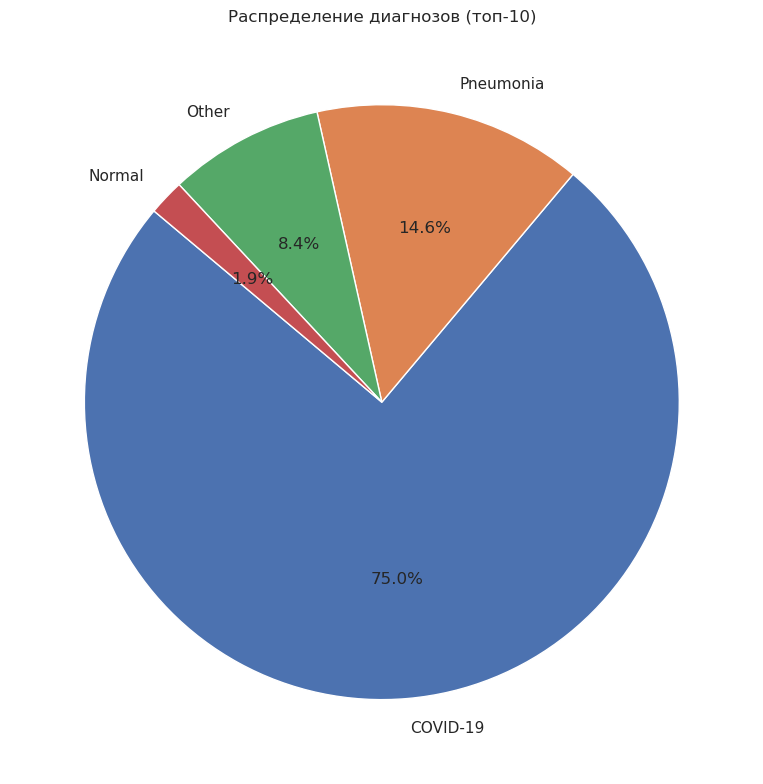

In [153]:
diag_counts_pd = (
    df_filtered
    .groupBy("diagnosis_norm")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)  # чтобы диаграмма была читабельной
    .toPandas()
)

plt.figure(figsize=(8, 8))
plt.pie(
    diag_counts_pd["count"],
    labels=diag_counts_pd["diagnosis_norm"],
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Распределение диагнозов (топ-10)")
plt.tight_layout()
plt.show()


**6.2. Столбчатая диаграмма по возрастным группам**

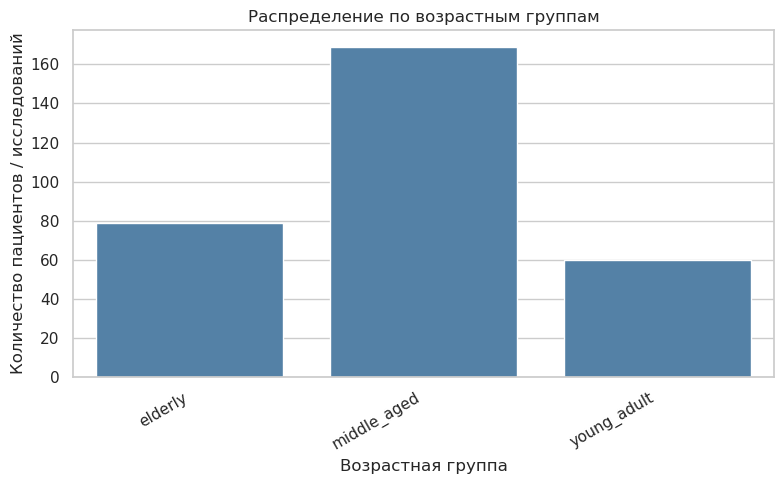

In [154]:
age_counts_pd = (
    df_filtered
    .groupBy("age_group")
    .count()
    .orderBy("age_group")
    .toPandas()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=age_counts_pd,
    x="age_group",
    y="count",
    color="steelblue"
)
plt.xlabel("Возрастная группа")
plt.ylabel("Количество пациентов / исследований")
plt.title("Распределение по возрастным группам")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**6.3. График временных трендов исследований**

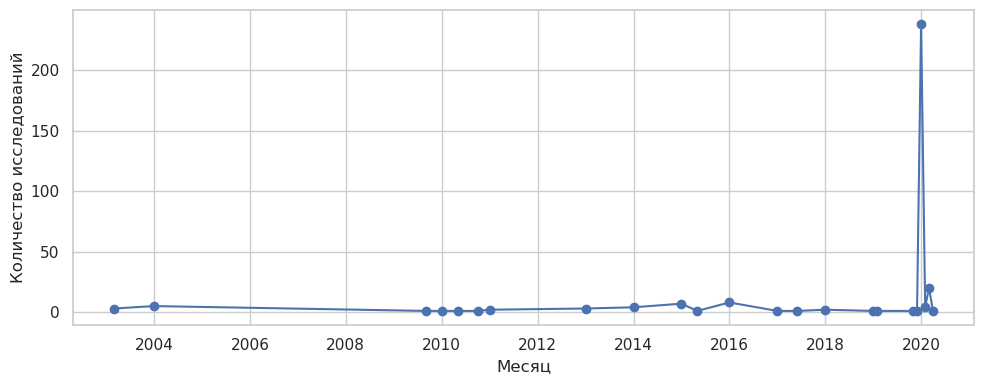

In [160]:
df_trend = (
    df_filtered
    .groupBy(F.date_trunc("month", "date_parsed").alias("month"))
    .count()
    .orderBy("month")
)

trend_pd = df_trend.toPandas()
# Лишняя строка — удалить:
# trend_pd["month"] = trend_pd["month"].dt.to_pydatetime()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(
    trend_pd["month"].to_numpy(),
    trend_pd["count"].to_numpy(),
    marker="o"
)
plt.xlabel("Месяц")
plt.ylabel("Количество исследований")
plt.grid(True)
plt.tight_layout()


**6.4. Heatmap распределения диагнозов по проекциям**

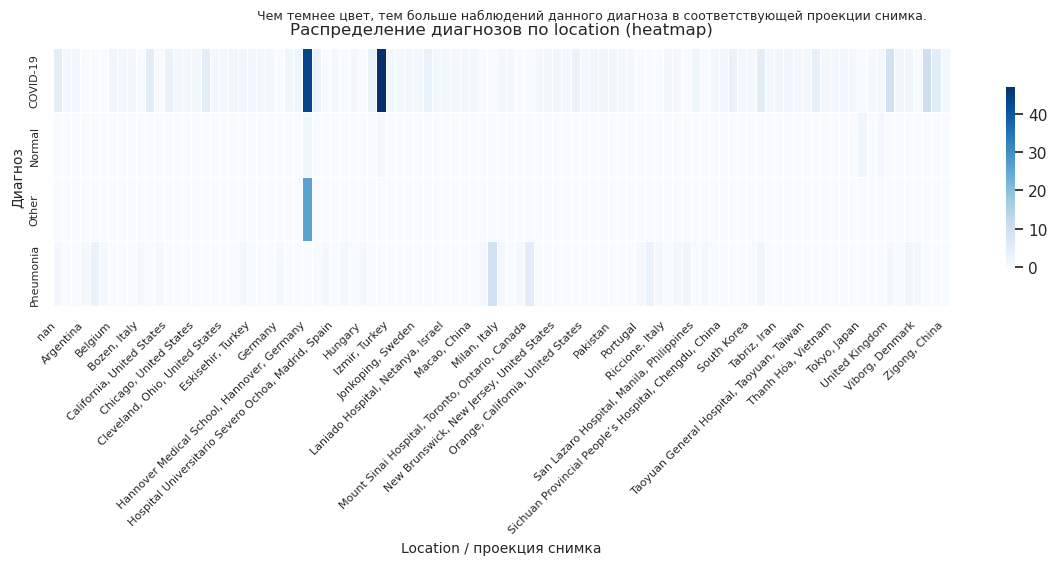

In [163]:
diag_proj_pd = (
    df_filtered
    .groupBy("diagnosis_norm", "location")
    .count()
    .toPandas()
)

# ограничим число диагнозов
top_diags = (
    diag_proj_pd.groupby("diagnosis_norm")["count"].sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)
diag_proj_pd = diag_proj_pd[diag_proj_pd["diagnosis_norm"].isin(top_diags)]

pivot = diag_proj_pd.pivot(
    index="diagnosis_norm",
    columns="location",
    values="count"
).fillna(0)

plt.figure(figsize=(12, max(6, 0.5 * len(pivot))))  # чуть шире

sns.heatmap(
    pivot,
    annot=False,
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"shrink": 0.7}  # уменьшить цветовую шкалу
)

# подписи осей и тиков
plt.xlabel("Location / проекция снимка", fontsize=10)
plt.ylabel("Диагноз", fontsize=10)

plt.xticks(
    rotation=45,       # поворот подписей по оси X
    ha="right",
    fontsize=8
)
plt.yticks(fontsize=8)

plt.title("Распределение диагнозов по location (heatmap)", fontsize=12, pad=10)

# короткое пояснение под заголовком
plt.suptitle(
    "Чем темнее цвет, тем больше наблюдений данного диагноза "
    "в соответствующей проекции снимка.",
    fontsize=9,
    y=0.94
)

plt.tight_layout()
plt.show()

8. Презентация

Слайд 1. Архитектура решения  

• Источник данных: DICOM/PNG-снимки + таблица с метаданными (пациент, дата, diagnosis_norm, location).

• Подготовка данных:

  – фильтрация по качеству и доступности разметки;
  
  – нормализация диагнозов (diagnosis_norm), очистка редких/ошибочных значений;
  
  – разбиение на train/valid/test с учётом пациента (нет утечек между выборками).
  
• Обработка изображений:

  – приведение к единому размеру;
  
  – нормализация интенсивностей;
  
  – аугментации (flip/rotate/brightness, при необходимости).
  
• Модель:

  – базовая архитектура (например, CNN / ResNet / EfficientNet);
  
  – вход: снимок +, при необходимости, табличные признаки;
  
  – выход: предсказание диагноза / вероятности классов.
  
• Обучение и валидация:

  – функция потерь (кросс-энтропия / BCE);
  
  – оптимизатор, lr-scheduler;
  
  – контроль переобучения (early stopping, регуляризация).
  
• Инференс и интеграция:

  – сервис предсказаний по входному снимку;
  
  – логирование результатов и метрик.
  

---

Слайд 2. Ключевые статистики  
(подставьте свои реальные числа)  
• Объём данных:
  – N пациентов, M снимков;
  – число уникальных диагнозов / классов.
• Баланс классов:
  – топ-5 диагнозов по частоте;
  – доля редких классов (ниже X наблюдений).
• Разметка и location:
  – распределение снимков по location (например, PA, AP, LAT);
  – сколько диагнозов в среднем приходится на одного пациента/снимок.
• Качество модели:
  – Accuracy / F1 / ROC-AUC (по основным классам);
  – метрики по ключевым диагнозам (например, пневмония, онкология и т.п.);
  – сравнение train vs valid (признаки переобучения/недообучения).

---

Слайд 3. Визуализации и выводы  
• Использованные визуализации:
  – гистограммы/барчарты распределения диагнозов и location;
  – heatmap «диагноз × location» (частоты);
  – ROC-кривые / PR-кривые для ключевых диагнозов;
  – примеры снимков с корректными и ошибочными предсказаниями модели.
• Основные наблюдения:
  – диагнозы распределены неравномерно; есть доминирующие и редкие классы;
  – часть диагнозов сильно «привязана» к определённым location (по heatmap);
  – модель лучше различает частые классы, качество по редким ниже;
  – на ошибках часто заметны: низкое качество снимков, нетипичная проекция, пересечение нескольких патологий.
• Выводы:
  – текущая архитектура даёт приемлемое качество по основным диагнозам;
  – ограничивающий фактор — дисбаланс классов и редкие диагнозы;
  – есть потенциал улучшения за счёт:
    ▪️ балансировки классов и дополнительных данных;
    ▪️ донастройки архитектуры/гиперпараметров;
    ▪️ использования клинических/табличных признаков вместе с изображениями.

Если скажете, для какого именно проекта это (класс задачи, данные, метрики), могу переписать текст уже под ваши реальные числа и термины.